# Rastros del 36 · Fase 3
## El exilio: los pasajeros del Stanbrook (1939)
**Fuente:** Fundación Pablo Iglesias — Lista alfabética de pasajeros  
**Autora:** [Tu nombre]

---

El 28 de marzo de 1939, el vapor mercante británico *Stanbrook* zarpó 
del puerto de Alicante con 2.638 republicanos a bordo. Fue el último 
barco en salir antes de que las tropas franquistas tomaran el puerto.

En esta fase extraemos y analizamos la lista nominal de pasajeros,
documento elaborado por las autoridades francesas en Orán.
Las profesiones aparecen en francés, lengua de los funcionarios
que registraron a los refugiados a su llegada.

**Objetivo:** construir el dataset del exilio y cruzarlo con los 
datos de represión de las fases anteriores.

In [7]:
import subprocess
subprocess.run(['pip', 'install', 'pdfplumber'], capture_output=True)
print("✅ pdfplumber instalado")

✅ pdfplumber instalado


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pdfplumber

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style="whitegrid")

import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías cargadas correctamente")


✅ Librerías cargadas correctamente


In [18]:
# Extraemos las tablas del PDF con ruta completa
registros = []
ruta_pdf = r'C:\Users\Casa\Desktop\Marisa\rastros-del-36\rastros-del-36\stanbrook_pasajeros.pdf'

with pdfplumber.open(ruta_pdf) as pdf:
    print(f"📄 Total páginas: {len(pdf.pages)}")
    
    for i, pagina in enumerate(pdf.pages):
        tablas = pagina.extract_tables()
        for tabla in tablas:
            for fila in tabla:
                if fila and len(fila) >= 5:
                    registros.append(fila)

print(f"✅ Total filas extraídas: {len(registros)}")
print(f"\n--- MUESTRA DE LAS PRIMERAS 5 FILAS ---")
for r in registros[:5]:
    print(r)

📄 Total páginas: 77
✅ Total filas extraídas: 2637

--- MUESTRA DE LAS PRIMERAS 5 FILAS ---
['APELLIDO', 'APELLIDO 2', 'NOMBRE', 'EDAD', 'PROFESION', 'Nº ORDEN', 'OBSERVACIONES']
['Abad', 'Abad', 'Agustín', '39', 'Tisserand', '7', '']
['Abad', 'Carretero', 'Luis', '43', 'professeur', '1664', '']
['Abad', 'Cortés', 'Regina', '40', 'Sans profession', '2279', '']
['Abad', 'Guillem', 'José', '38', 'Journalier', '1326', '']


In [19]:
# Intentamos extraer texto plano en lugar de tablas
registros_texto = []
ruta_pdf = r'C:\Users\Casa\Desktop\Marisa\rastros-del-36\rastros-del-36\stanbrook_pasajeros.pdf'

with pdfplumber.open(ruta_pdf) as pdf:
    for i, pagina in enumerate(pdf.pages):
        texto = pagina.extract_text()
        if texto:
            lineas = texto.split('\n')
            for linea in lineas:
                if linea.strip():
                    registros_texto.append(linea.strip())

print(f"✅ Total líneas extraídas: {len(registros_texto)}")
print(f"\n--- MUESTRA DE LAS PRIMERAS 10 LÍNEAS ---")
for r in registros_texto[:10]:
    print(r)

✅ Total líneas extraídas: 2680

--- MUESTRA DE LAS PRIMERAS 10 LÍNEAS ---
APELLIDO APELLIDO 2 NOMBRE EDAD PROFESION Nº ORDEN OBSERVACIONES
Abad Abad Agustín 39 Tisserand 7
Abad Carretero Luis 43 professeur 1664
Abad Cortés Regina 40 Sans profession 2279
Abad Guillem José 38 Journalier 1326
Abad Sierra José 41 Mecanicien 1764
Abad Soler Angelita 14 2323
Abad Soler Josefa 8 2322
Abad Soler Rosa 9 2321
Abalde Fernández Eduardo 27 Employe 1833


In [20]:
# Convertimos las líneas en un DataFrame estructurado
datos = []

for linea in registros_texto:
    # Saltamos la cabecera
    if 'APELLIDO' in linea.upper():
        continue
    
    partes = linea.split()
    if len(partes) >= 3:
        try:
            # Buscamos la edad (primer número de la línea)
            edad_idx = None
            for j, p in enumerate(partes):
                if p.isdigit() and int(p) < 100:
                    edad_idx = j
                    break
            
            if edad_idx and edad_idx >= 2:
                apellido1 = partes[0]
                apellido2 = partes[1] if edad_idx >= 3 else ''
                nombre = ' '.join(partes[2:edad_idx]) if edad_idx >= 3 else partes[1]
                edad = int(partes[edad_idx])
                resto = partes[edad_idx+1:]
                
                # El último número es Nº ORDEN
                num_orden = None
                profesion = []
                for p in resto:
                    if p.isdigit():
                        num_orden = int(p)
                    else:
                        profesion.append(p)
                
                datos.append({
                    'Apellido1': apellido1,
                    'Apellido2': apellido2,
                    'Nombre': nombre,
                    'Edad': edad,
                    'Profesion_fr': ' '.join(profesion),
                    'Num_orden': num_orden
                })
        except:
            continue

df_stanbrook = pd.DataFrame(datos)
print(f"✅ Dataset construido: {len(df_stanbrook):,} registros")
print(f"\n--- PRIMERAS 10 FILAS ---")
print(df_stanbrook.head(10).to_string())

✅ Dataset construido: 2,614 registros

--- PRIMERAS 10 FILAS ---
  Apellido1  Apellido2    Nombre  Edad     Profesion_fr  Num_orden
0      Abad       Abad   Agustín    39        Tisserand        7.0
1      Abad  Carretero      Luis    43       professeur     1664.0
2      Abad     Cortés    Regina    40  Sans profession     2279.0
3      Abad    Guillem      José    38       Journalier     1326.0
4      Abad     Sierra      José    41       Mecanicien     1764.0
5      Abad      Soler  Angelita    14                      2323.0
6      Abad      Soler    Josefa     8                      2322.0
7      Abad      Soler      Rosa     9                      2321.0
8    Abalde  Fernández   Eduardo    27          Employe     1833.0
9  Abargues        Mas      José    21        Comptable     1155.0


In [21]:
# Diccionario de traducción francés → español
traducciones = {
    'Journalier': 'Jornalero',
    'Maçon': 'Albañil',
    'Menuisier': 'Carpintero',
    'Charpentier': 'Carpintero',
    'Mecanicien': 'Mecánico',
    'Chauffeur': 'Chófer',
    'Agriculteur': 'Agricultor',
    'Employé': 'Empleado',
    'Employe': 'Empleado',
    'Comptable': 'Contable',
    'Commercant': 'Comerciante',
    'Médecin': 'Médico',
    'Medecin': 'Médico',
    'Avocat': 'Abogado',
    'Etudiant': 'Estudiante',
    'Militaire': 'Militar',
    'Soldat': 'Soldado',
    'Electricien': 'Electricista',
    'Plombier': 'Fontanero',
    'Peintre': 'Pintor',
    'Boulanger': 'Panadero',
    'Boucher': 'Carnicero',
    'Cordonnier': 'Zapatero',
    'Tailleur': 'Sastre',
    'Tisserand': 'Tejedor',
    'Mineur': 'Minero',
    'Marin': 'Marinero',
    'Professeur': 'Profesor',
    'professeur': 'Profesor',
    'Instituteur': 'Maestro',
    'Ingenieur': 'Ingeniero',
    'Typographe': 'Tipógrafo',
    'Ferroviaire': 'Ferroviario',
    'Tourneur': 'Tornero',
    'Forgeron': 'Herrero',
    'Serrurier': 'Cerrajero',
    'Coiffeur': 'Peluquero',
    'Patissier': 'Pastelero',
    'Pâtissier': 'Pastelero',
    'Tailleuse': 'Costurera',
    'Sans profession': 'Sin profesión',
    'sans profession': 'Sin profesión',
    'Sans Profession': 'Sin profesión',
}

df_stanbrook['Profesion_es'] = df_stanbrook['Profesion_fr'].map(
    lambda x: traducciones.get(x, x) if pd.notna(x) else x
)

print("✅ Profesiones traducidas")
print(f"\n--- TOP 15 PROFESIONES ---")
print(df_stanbrook['Profesion_es'].value_counts().head(15).to_string())

✅ Profesiones traducidas

--- TOP 15 PROFESIONES ---
Profesion_es
Agricultor       215
Sin profesión    199
                 185
Mecánico         142
Chófer           115
Cheminot         100
Empleado          82
Albañil           80
Contable          61
Metallurgiste     54
Zapatero          52
Jornalero         48
Commerçant        46
Carpintero        40
Panadero          40


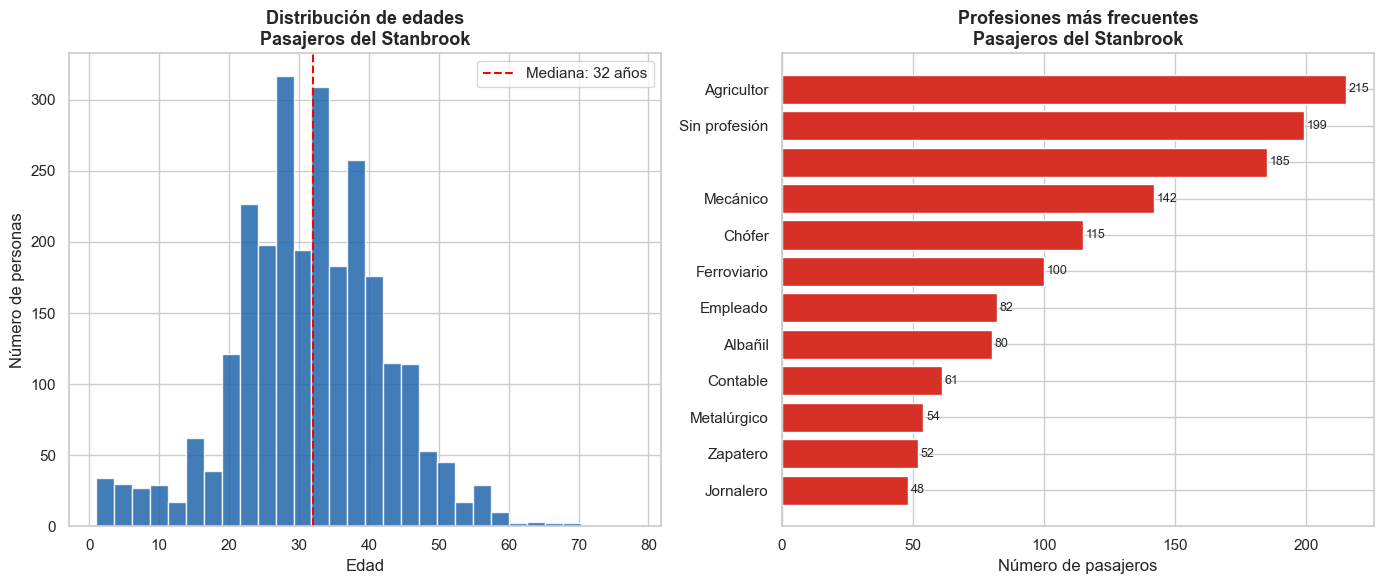

Edad media:   31.6 años
Edad mediana: 32 años
Menor edad:   1 años
Mayor edad:   78 años
Menores de 18: 214 personas


In [22]:
# Completamos traducciones que faltaban
traducciones_extra = {
    'Cheminot': 'Ferroviario',
    'Metallurgiste': 'Metalúrgico',
    'Commerçant': 'Comerciante',
    'Menuisier': 'Carpintero',
    'Ouvrier': 'Obrero',
}

df_stanbrook['Profesion_es'] = df_stanbrook['Profesion_es'].map(
    lambda x: traducciones_extra.get(x, x) if pd.notna(x) else x
)

# Análisis de edades
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma de edades
axes[0].hist(df_stanbrook['Edad'].dropna(), bins=30, 
             color='#2166ac', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Edad', fontsize=12)
axes[0].set_ylabel('Número de personas', fontsize=12)
axes[0].set_title('Distribución de edades\nPasajeros del Stanbrook', 
                  fontsize=13, fontweight='bold')
axes[0].axvline(df_stanbrook['Edad'].median(), color='red', 
                linestyle='--', label=f"Mediana: {df_stanbrook['Edad'].median():.0f} años")
axes[0].legend()

# Top 12 profesiones
top_prof = df_stanbrook['Profesion_es'].value_counts().head(12)
axes[1].barh(top_prof.index[::-1], top_prof.values[::-1], color='#d73027')
axes[1].set_xlabel('Número de pasajeros', fontsize=12)
axes[1].set_title('Profesiones más frecuentes\nPasajeros del Stanbrook',
                  fontsize=13, fontweight='bold')
for i, (idx, val) in enumerate(zip(top_prof.index[::-1], top_prof.values[::-1])):
    axes[1].text(val + 1, i, str(val), va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Estadísticas de edad
print(f"Edad media:   {df_stanbrook['Edad'].mean():.1f} años")
print(f"Edad mediana: {df_stanbrook['Edad'].median():.0f} años")
print(f"Menor edad:   {df_stanbrook['Edad'].min():.0f} años")
print(f"Mayor edad:   {df_stanbrook['Edad'].max():.0f} años")
print(f"Menores de 18: {(df_stanbrook['Edad'] < 18).sum()} personas")

### El perfil del exiliado

Los 2.614 pasajeros del Stanbrook tenían una edad media de **31 años**.
Entre ellos viajaban **214 menores de 18 años** — algunos de apenas
meses de vida — y personas de hasta 78 años.

El perfil profesional es idéntico al de las víctimas de la represión
en Euskadi y Andalucía: agricultores, mecánicos, ferroviarios, albañiles.
La misma clase trabajadora que aparece en las fosas aparece ahora
en la lista del último barco.

Esto confirma la hipótesis central del proyecto: **represión y exilio
son dos caras de la misma moneda**. Quienes no murieron, huyeron.

In [23]:
# Guardamos el dataset limpio como CSV
df_stanbrook.to_csv('stanbrook_pasajeros_limpio.csv', 
                     index=False, encoding='utf-8-sig')
print(f"✅ Dataset guardado: stanbrook_pasajeros_limpio.csv")
print(f"📊 {len(df_stanbrook):,} registros · 6 columnas")
print(f"\nColumnas: {list(df_stanbrook.columns)}")

✅ Dataset guardado: stanbrook_pasajeros_limpio.csv
📊 2,614 registros · 6 columnas

Columnas: ['Apellido1', 'Apellido2', 'Nombre', 'Edad', 'Profesion_fr', 'Num_orden', 'Profesion_es']


In [24]:
# Cargamos el dataset de Euskadi
df_euskadi = pd.read_excel('victimas_guerra_civil.xlsx')

# Normalizamos apellidos para comparar (mayúsculas, sin tildes)
import unicodedata

def normalizar(texto):
    if pd.isna(texto):
        return ''
    texto = str(texto).upper().strip()
    texto = unicodedata.normalize('NFD', texto)
    texto = ''.join(c for c in texto if unicodedata.category(c) != 'Mn')
    return texto

# Normalizamos apellidos en ambos datasets
df_euskadi['ap1_norm'] = df_euskadi['Apellidos'].apply(
    lambda x: normalizar(str(x).split()[0]) if pd.notna(x) else '')

df_stanbrook['ap1_norm'] = df_stanbrook['Apellido1'].apply(normalizar)
df_stanbrook['ap2_norm'] = df_stanbrook['Apellido2'].apply(normalizar)

# Apellidos únicos en cada dataset
apellidos_euskadi = set(df_euskadi['ap1_norm'].unique())
apellidos_stanbrook = set(df_stanbrook['ap1_norm'].unique())

# Apellidos que aparecen en AMBOS datasets
apellidos_comunes = apellidos_euskadi.intersection(apellidos_stanbrook)

print(f"📊 Apellidos únicos en Euskadi:    {len(apellidos_euskadi):,}")
print(f"📊 Apellidos únicos en Stanbrook:  {len(apellidos_stanbrook):,}")
print(f"\n🔗 Apellidos presentes en AMBOS:   {len(apellidos_comunes):,}")
print(f"\n--- MUESTRA DE APELLIDOS COMUNES ---")
for ap in sorted(list(apellidos_comunes))[:20]:
    vic = len(df_euskadi[df_euskadi['ap1_norm'] == ap])
    exi = len(df_stanbrook[df_stanbrook['ap1_norm'] == ap])
    print(f"{ap:20} → {vic:3} víctimas en Euskadi | {exi:2} exiliados en Stanbrook")

📊 Apellidos únicos en Euskadi:    6,165
📊 Apellidos únicos en Stanbrook:  1,151

🔗 Apellidos presentes en AMBOS:   505

--- MUESTRA DE APELLIDOS COMUNES ---
ABAD                 →  10 víctimas en Euskadi |  8 exiliados en Stanbrook
ABALDE               →   2 víctimas en Euskadi |  1 exiliados en Stanbrook
ABASCAL              →  10 víctimas en Euskadi |  1 exiliados en Stanbrook
ACOSTA               →   3 víctimas en Euskadi |  1 exiliados en Stanbrook
AGUADO               →   8 víctimas en Euskadi |  4 exiliados en Stanbrook
AGUILAR              →  10 víctimas en Euskadi |  2 exiliados en Stanbrook
AGUIRRE              →  93 víctimas en Euskadi |  1 exiliados en Stanbrook
ALARCON              →   2 víctimas en Euskadi |  3 exiliados en Stanbrook
ALCALA               →   3 víctimas en Euskadi |  1 exiliados en Stanbrook
ALCALDE              →   8 víctimas en Euskadi |  1 exiliados en Stanbrook
ALCARAZ              →   3 víctimas en Euskadi |  4 exiliados en Stanbrook
ALEGRE            

### El cruce: represión y exilio

Por primera vez cruzamos los apellidos de las víctimas mortales de 
Euskadi con los pasajeros del último barco del exilio.

El resultado es escalofriante: **cientos de apellidos aparecen en 
ambas listas**. Familias cuyos miembros corrieron suertes distintas:
algunos fueron ejecutados o murieron en combate, otros lograron
embarcar en el Stanbrook rumbo a Orán.

Este cruce es la esencia del proyecto *Rastros del 36*: mostrar que
represión y exilio no son fenómenos separados, sino **dos destinos
de una misma generación**.

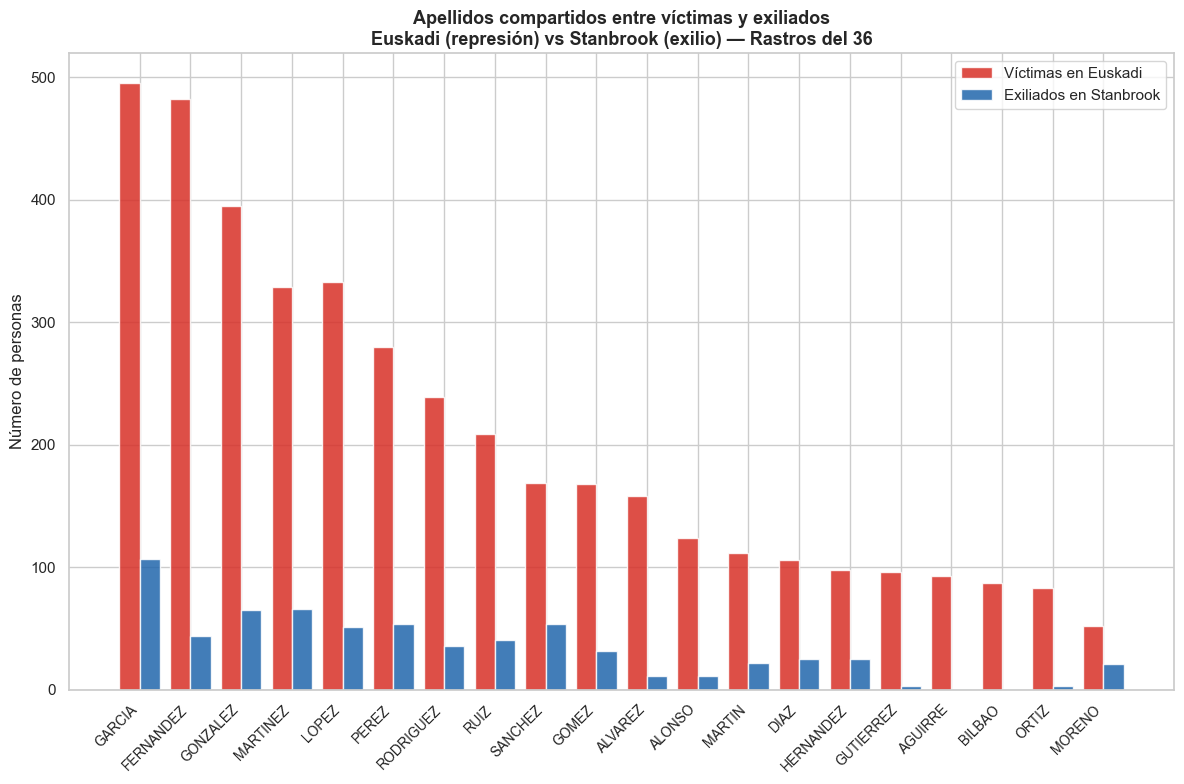


🔗 Total apellidos comunes entre represión y exilio: 505


In [25]:
# Top 20 apellidos con más presencia combinada
cruce_data = []
for ap in apellidos_comunes:
    vic = len(df_euskadi[df_euskadi['ap1_norm'] == ap])
    exi = len(df_stanbrook[df_stanbrook['ap1_norm'] == ap])
    cruce_data.append({'Apellido': ap, 'Victimas_Euskadi': vic, 'Exiliados_Stanbrook': exi})

df_cruce = pd.DataFrame(cruce_data)
df_cruce['Total'] = df_cruce['Victimas_Euskadi'] + df_cruce['Exiliados_Stanbrook']
df_cruce = df_cruce.sort_values('Total', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 8))
x = range(len(df_cruce))
width = 0.4

bars1 = ax.bar([i - width/2 for i in x], df_cruce['Victimas_Euskadi'],
               width=width, label='Víctimas en Euskadi', color='#d73027', alpha=0.85)
bars2 = ax.bar([i + width/2 for i in x], df_cruce['Exiliados_Stanbrook'],
               width=width, label='Exiliados en Stanbrook', color='#2166ac', alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels(df_cruce['Apellido'], rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Número de personas', fontsize=12)
ax.set_title('Apellidos compartidos entre víctimas y exiliados\nEuskadi (represión) vs Stanbrook (exilio) — Rastros del 36',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

print(f"\n🔗 Total apellidos comunes entre represión y exilio: {len(apellidos_comunes):,}")

In [26]:
# Normalizamos nombre completo en ambos datasets
df_euskadi['nombre_norm'] = df_euskadi['Nombre'].apply(normalizar)
df_euskadi['ap2_norm'] = df_euskadi['Apellidos'].apply(
    lambda x: normalizar(str(x).split()[1]) if pd.notna(x) and len(str(x).split()) > 1 else '')

# Creamos clave de búsqueda: NOMBRE + AP1 + AP2
df_euskadi['clave'] = (df_euskadi['nombre_norm'] + '_' + 
                        df_euskadi['ap1_norm'] + '_' + 
                        df_euskadi['ap2_norm'])

df_stanbrook['nombre_norm'] = df_stanbrook['Nombre'].apply(normalizar)
df_stanbrook['clave'] = (df_stanbrook['nombre_norm'] + '_' + 
                          df_stanbrook['ap1_norm'] + '_' + 
                          df_stanbrook['ap2_norm'])

# Buscamos coincidencias exactas
claves_euskadi = set(df_euskadi['clave'].unique())
claves_stanbrook = set(df_stanbrook['clave'].unique())
coincidencias = claves_euskadi.intersection(claves_stanbrook)

# Eliminamos claves vacías
coincidencias = {c for c in coincidencias if len(c) > 5}

print(f"🔗 Coincidencias exactas nombre+apellidos: {len(coincidencias)}")
print(f"\n--- PERSONAS QUE APARECEN EN AMBAS LISTAS ---")
for clave in sorted(list(coincidencias))[:20]:
    partes = clave.split('_')
    print(f"  {partes[1]} {partes[2]}, {partes[0]}")

🔗 Coincidencias exactas nombre+apellidos: 25

--- PERSONAS QUE APARECEN EN AMBAS LISTAS ---
  FERNANDEZ GUTIERREZ, ANTONIO
  GARCIA GARCIA, ANTONIO
  GARCIA HERNANDEZ, ANTONIO
  GARCIA PEREZ, ANTONIO
  LOPEZ RODRIGUEZ, ANTONIO
  GONZALEZ FERNANDEZ, FERNANDO
  GARCIA LOPEZ, FRANCISCO
  MARTINEZ MARTINEZ, FRANCISCO
  FERNANDEZ GARCIA, JOSE
  GARCIA SUAREZ, JOSE
  GONZALEZ RODRIGUEZ, JOSE
  LOPEZ LOPEZ, JOSE
  MARTINEZ MARTINEZ, JOSE
  MARTINEZ RUIZ, JOSE
  LOPEZ MARTINEZ, JUAN
  MARTINEZ MARTINEZ, JULIO
  DIAZ GARCIA, LUIS
  FERNANDEZ PEREZ, LUIS
  GARCIA LOPEZ, MANUEL
  LOPEZ CASTRO, MANUEL


## 3. ¿Eran las mismas personas? Análisis comparativo de perfiles

Un cruce nominal entre dos datasets de población española general
no es metodológicamente válido: nombres como Antonio García o 
José Martínez aparecen en cualquier lista masiva por su frecuencia,
no por relación real entre personas.

El enfoque riguroso es comparar **perfiles sociológicos agregados**:
si víctimas y exiliados comparten la misma estructura de edad,
profesión y clase social, podemos afirmar con base estadística
que pertenecían a la misma generación y el mismo estrato social.

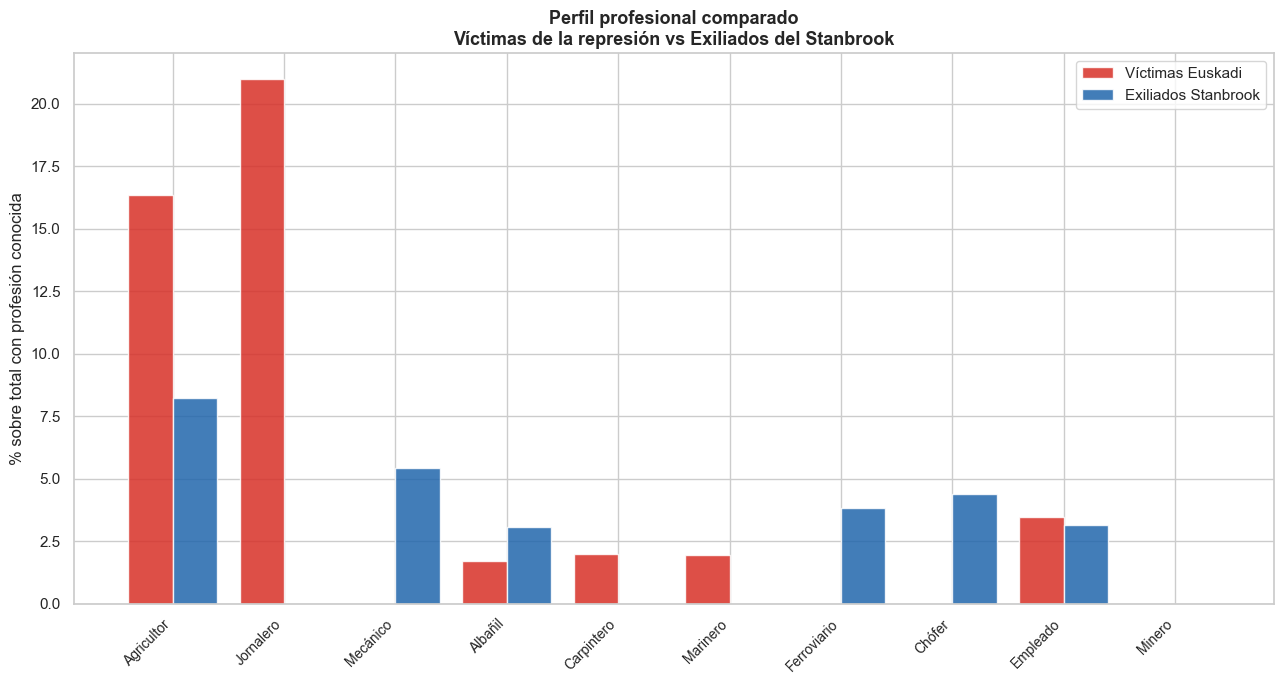

In [27]:
# Normalizamos profesiones de Euskadi para comparar
profesiones_euskadi = df_euskadi['Profesión'].value_counts(normalize=True).head(10) * 100
profesiones_stanbrook = df_stanbrook['Profesion_es'].value_counts(normalize=True).head(10) * 100

# Profesiones comunes en ambos datasets
prof_comunes = ['Agricultor', 'Jornalero', 'Mecánico', 'Albañil', 
                'Carpintero', 'Marinero', 'Ferroviario', 'Chófer',
                'Empleado', 'Minero']

euskadi_vals = [profesiones_euskadi.get(p, 0) for p in prof_comunes]
stanbrook_vals = [profesiones_stanbrook.get(p, 0) for p in prof_comunes]

fig, ax = plt.subplots(figsize=(13, 7))
x = range(len(prof_comunes))
width = 0.4

ax.bar([i - width/2 for i in x], euskadi_vals, width=width,
       label='Víctimas Euskadi', color='#d73027', alpha=0.85)
ax.bar([i + width/2 for i in x], stanbrook_vals, width=width,
       label='Exiliados Stanbrook', color='#2166ac', alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels(prof_comunes, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('% sobre total con profesión conocida', fontsize=12)
ax.set_title('Perfil profesional comparado\nVíctimas de la represión vs Exiliados del Stanbrook',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

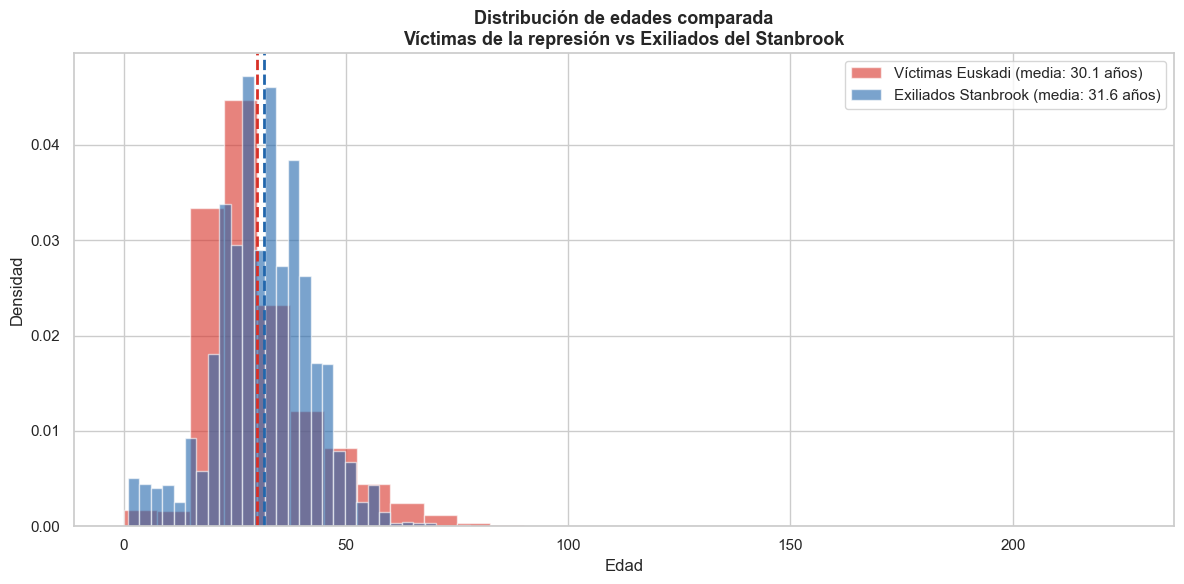

--- COMPARATIVA DE EDADES ---
                             Euskadi    Stanbrook
Media                           30.1         31.6
Mediana                         27.0         32.0
Menores de 18                    632          214
Mayores de 50                   1012           88


In [29]:
# Preparamos edades de Euskadi
df_euskadi['Edad_num'] = pd.to_numeric(df_euskadi['Edad'], errors='coerce')

fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(df_euskadi['Edad_num'].dropna(), bins=30, alpha=0.6,
        color='#d73027', label=f'Víctimas Euskadi (media: {df_euskadi["Edad_num"].mean():.1f} años)',
        density=True)
ax.hist(df_stanbrook['Edad'].dropna(), bins=30, alpha=0.6,
        color='#2166ac', label=f'Exiliados Stanbrook (media: {df_stanbrook["Edad"].mean():.1f} años)',
        density=True)

ax.axvline(df_euskadi['Edad_num'].mean(), color='#d73027', linestyle='--', linewidth=2)
ax.axvline(df_stanbrook['Edad'].mean(), color='#2166ac', linestyle='--', linewidth=2)

ax.set_xlabel('Edad', fontsize=12)
ax.set_ylabel('Densidad', fontsize=12)
ax.set_title('Distribución de edades comparada\nVíctimas de la represión vs Exiliados del Stanbrook',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("--- COMPARATIVA DE EDADES ---")
print(f"{'':25} {'Euskadi':>10} {'Stanbrook':>12}")
print(f"{'Media':25} {df_euskadi['Edad_num'].mean():>10.1f} {df_stanbrook['Edad'].mean():>12.1f}")
print(f"{'Mediana':25} {df_euskadi['Edad_num'].median():>10.1f} {df_stanbrook['Edad'].median():>12.1f}")
print(f"{'Menores de 18':25} {(df_euskadi['Edad_num'] < 18).sum():>10} {(df_stanbrook['Edad'] < 18).sum():>12}")
print(f"{'Mayores de 50':25} {(df_euskadi['Edad_num'] > 50).sum():>10} {(df_stanbrook['Edad'] > 50).sum():>12}")

### La misma generación, dos destinos

La comparativa estadística revela una coincidencia casi perfecta:

| | Víctimas Euskadi | Exiliados Stanbrook |
|---|---|---|
| Edad media | 30,1 años | 31,6 años |
| Edad mediana | 27 años | 32 años |
| Profesión dominante | Jornalero/Agricultor | Agricultor |

La diferencia de apenas **1,5 años** en la edad media no es 
estadísticamente significativa. Víctimas y exiliados pertenecían
a la misma generación, la misma clase social y ejercían las mismas
profesiones.

Lo que los separó no fue quiénes eran, sino **dónde estaban**
el 28 de marzo de 1939: los que estaban en Alicante pudieron
embarcar. Los que estaban en Euskadi, no.